In [1]:
#E - commerce Sales Analysis using pandas

## Project objective - The objective of the project is to analyze e commerce sales data using pandas 
#                     and extract meaningful business insights


##Tools & Technologies
- Python
- Pandas
- Numpy
- Matplotlib
- Jupyter Notebook


import pandas as pd
import numpy as np 
np.random.seed(42)

n = 500

cities = ["Delhi","Mumbai","Bangalore","Pune","Indore","Sagar","Jaipur","Lucknow","Kolkata"]

categories = ["Electronics","Clothing","Home & Kitchen","Beauty","Books"]

products = {
    "Electronics" : ["Laptop","Headphones","Smartphone","Keyboard","Mouse"],
    "Clothing" : ["T-Shirt","Jeans","Jacket","Kurti","Shoes"],
    "Home & Kitchen" : ["Mixer","Cooker","Bedsheet","Lamp","Bottle"],
    "Beauty" : ["Face wash","Lipstick","Shampoo","Perfume","Moisturizer"],
    "Books" : ["Python Book","Novel","DSA Book","Biography","Mathematics"]
}

payment_modes = ["UPI","Credit Card","Debit Card","Cash on Delivery","Net Banking"]

order_status = ["Delivered","Delivered","Delivered","Cancelled","Returned"]

customer_names = ["Aarav","Priya","Rahul","Ananya","Rohan","Sneha","Aditya","Neha","Vivek","Pooja","Karan","Isha","Arjun","Simran","Nikhil"]

data = []

for i in range (n):
    category = np.random.choice(categories)
    product = np.random.choice(products[category])

    data.append([
        f"ORD{i + 1001}", 
        pd.Timestamp("2025-01-01") + pd.Timedelta(days = np.random.randint(0,365)),
        f"CUST{np.random.randint(101,201)}",

    np.random.choice(customer_names),
              np.random.choice(cities),
              category,
              product,
              np.random.randint(1,6),
              np.random.randint(200,80000),
              np.random.choice([0,5,10,15,20]),

    np.random.choice(payment_modes),

    np.random.choice(order_status)
        ])

df = pd.DataFrame(data,columns=[
    "Order_ID",
    "Order_Dates",
    "Customer_ID",
    "Customer_Name",
    "City",
    "Category",
    "Product",
    "Quantity",
    "Price",
    "Discount",
    "Payment_Modes",
    "Order_Status"
])
df.head()

,Order_ID,Order_Dates,Customer_ID,Customer_Name,City,Category,Product,Quantity,Price,Discount,Payment_Modes,Order_Status
0,ORD1001,2025-09-28,CUST172,Arjun,Indore,Beauty,Moisturizer,2,37394,10,Net Banking,Cancelled
1,ORD1002,2025-09-15,CUST188,Isha,Sagar,Home & Kitchen,Bottle,2,5511,15,Net Banking,Delivered
2,ORD1003,2025-01-22,CUST189,Aarav,Bangalore,Beauty,Lipstick,4,57086,15,UPI,Delivered
3,ORD1004,2025-05-15,CUST121,Vivek,Jaipur,Books,DSA Book,2,10827,0,Cash on Delivery,Delivered
4,ORD1005,2025-12-12,CUST153,Priya,Pune,Clothing,T-Shirt,4,23683,15,Net Banking,Delivered


In [2]:
#data inspection
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.columns
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       500 non-null    object        
 1   Order_Dates    500 non-null    datetime64[ns]
 2   Customer_ID    500 non-null    object        
 3   Customer_Name  500 non-null    object        
 4   City           500 non-null    object        
 5   Category       500 non-null    object        
 6   Product        500 non-null    object        
 7   Quantity       500 non-null    int64         
 8   Price          500 non-null    int64         
 9   Discount       500 non-null    int64         
 10  Payment_Modes  500 non-null    object        
 11  Order_Status   500 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 47.0+ KB


Order_ID                 object
Order_Dates      datetime64[ns]
Customer_ID              object
Customer_Name            object
City                     object
Category                 object
Product                  object
Quantity                  int64
Price                     int64
Discount                  int64
Payment_Modes            object
Order_Status             object
dtype: object

In [3]:
df['City'].unique
df['Category'].unique
df['Order_Status'].unique

<bound method Series.unique of 0      Cancelled
1      Delivered
2      Delivered
3      Delivered
4      Delivered
         ...    
495    Cancelled
496    Cancelled
497    Delivered
498    Delivered
499     Returned
Name: Order_Status, Length: 500, dtype: object>

In [4]:
#data cleaning 
df = pd.concat([df,df.iloc[[10,20,30]]] , ignore_index= True)
df
df[df.duplicated()]

,Order_ID,Order_Dates,Customer_ID,Customer_Name,City,Category,Product,Quantity,Price,Discount,Payment_Modes,Order_Status
500,ORD1011,2025-06-21,CUST186,Karan,Bangalore,Books,DSA Book,1,8310,10,UPI,Returned
501,ORD1021,2025-09-24,CUST192,Vivek,Kolkata,Clothing,T-Shirt,2,47454,5,Debit Card,Cancelled
502,ORD1031,2025-09-30,CUST133,Vivek,Sagar,Clothing,Jeans,5,6001,5,Debit Card,Delivered


In [5]:
df.duplicated().sum()

np.int64(3)

In [6]:
df = df.drop_duplicates()

In [7]:
df.shape

(500, 12)

In [8]:
df.loc[3,"City"] = np.nan
df.loc[4,"Category"] = np.nan
df.loc[1,"Customer_Name"] = np.nan
df.loc[499,"Payment_Modes"] = np.nan
df
df.isnull().sum()

Order_ID         0
Order_Dates      0
Customer_ID      0
Customer_Name    1
City             1
Category         1
Product          0
Quantity         0
Price            0
Discount         0
Payment_Modes    1
Order_Status     0
dtype: int64

In [9]:
df[df.isnull().any(axis = 1)]

,Order_ID,Order_Dates,Customer_ID,Customer_Name,City,Category,Product,Quantity,Price,Discount,Payment_Modes,Order_Status
1,ORD1002,2025-09-15,CUST188,NaN,Sagar,Home & Kitchen,Bottle,2,5511,15,Net Banking,Delivered
3,ORD1004,2025-05-15,CUST121,Vivek,NaN,Books,DSA Book,2,10827,0,Cash on Delivery,Delivered
4,ORD1005,2025-12-12,CUST153,Priya,Pune,NaN,T-Shirt,4,23683,15,Net Banking,Delivered
499,ORD1500,2025-07-18,CUST146,Nikhil,Delhi,Books,Mathematics,1,30205,15,NaN,Returned


In [10]:
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Customer_Name"] = df["Customer_Name"].fillna("Unknown")
df["Category"] = df["Category"].fillna("Unknown")
df["Payment_Modes"] = df["Payment_Modes"].fillna("Money")
df

,Order_ID,Order_Dates,Customer_ID,Customer_Name,City,Category,Product,Quantity,Price,Discount,Payment_Modes,Order_Status
0,ORD1001,2025-09-28,CUST172,Arjun,Indore,Beauty,Moisturizer,2,37394,10,Net Banking,Cancelled
1,ORD1002,2025-09-15,CUST188,Unknown,Sagar,Home & Kitchen,Bottle,2,5511,15,Net Banking,Delivered
2,ORD1003,2025-01-22,CUST189,Aarav,Bangalore,Beauty,Lipstick,4,57086,15,UPI,Delivered
3,ORD1004,2025-05-15,CUST121,Vivek,Bangalore,Books,DSA Book,2,10827,0,Cash on Delivery,Delivered
4,ORD1005,2025-12-12,CUST153,Priya,Pune,Unknown,T-Shirt,4,23683,15,Net Banking,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORD1496,2025-06-08,CUST157,Simran,Mumbai,Home & Kitchen,Cooker,5,41686,15,Net Banking,Cancelled
496,ORD1497,2025-12-25,CUST124,Rohan,Indore,Beauty,Moisturizer,2,59295,5,Credit Card,Cancelled
497,ORD1498,2025-01-22,CUST178,Nikhil,Pune,Beauty,Moisturizer,1,27764,15,Cash on Delivery,Delivered
498,ORD1499,2025-05-03,CUST116,Karan,Indore,Home & Kitchen,Bottle,4,76636,10,Cash on Delivery,Delivered


In [11]:
df["City"].value_counts()
df["Category"].value_counts()
df["Product"].value_counts()
df["Order_Status"].value_counts()

Order_Status
Delivered    318
Returned      94
Cancelled     88
Name: count, dtype: int64

In [12]:
#feature  engineering
df["Gross_Amount"] = df["Quantity"]*df["Price"]
df


,Order_ID,Order_Dates,Customer_ID,Customer_Name,City,Category,Product,Quantity,Price,Discount,Payment_Modes,Order_Status,Gross_Amount
0,ORD1001,2025-09-28,CUST172,Arjun,Indore,Beauty,Moisturizer,2,37394,10,Net Banking,Cancelled,74788
1,ORD1002,2025-09-15,CUST188,Unknown,Sagar,Home & Kitchen,Bottle,2,5511,15,Net Banking,Delivered,11022
2,ORD1003,2025-01-22,CUST189,Aarav,Bangalore,Beauty,Lipstick,4,57086,15,UPI,Delivered,228344
3,ORD1004,2025-05-15,CUST121,Vivek,Bangalore,Books,DSA Book,2,10827,0,Cash on Delivery,Delivered,21654
4,ORD1005,2025-12-12,CUST153,Priya,Pune,Unknown,T-Shirt,4,23683,15,Net Banking,Delivered,94732
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORD1496,2025-06-08,CUST157,Simran,Mumbai,Home & Kitchen,Cooker,5,41686,15,Net Banking,Cancelled,208430
496,ORD1497,2025-12-25,CUST124,Rohan,Indore,Beauty,Moisturizer,2,59295,5,Credit Card,Cancelled,118590
497,ORD1498,2025-01-22,CUST178,Nikhil,Pune,Beauty,Moisturizer,1,27764,15,Cash on Delivery,Delivered,27764
498,ORD1499,2025-05-03,CUST116,Karan,Indore,Home & Kitchen,Bottle,4,76636,10,Cash on Delivery,Delivered,306544


In [13]:
df[["Quantity","Price","Gross_Amount"]].head()


,Quantity,Price,Gross_Amount
0,2,37394,74788
1,2,5511,11022
2,4,57086,228344
3,2,10827,21654
4,4,23683,94732


In [14]:
df["Discount_Amount"] = df["Gross_Amount"]*df["Discount"]/100
df
df[["Gross_Amount","Discount","Discount_Amount"]].head()

,Gross_Amount,Discount,Discount_Amount
0,74788,10,7478.8
1,11022,15,1653.3
2,228344,15,34251.6
3,21654,0,0.0
4,94732,15,14209.8


In [15]:
df["Final_Amount"] = df["Gross_Amount"] - df["Discount_Amount"]
df
df[["Gross_Amount","Discount_Amount","Final_Amount"]].head()

,Gross_Amount,Discount_Amount,Final_Amount
0,74788,7478.8,67309.2
1,11022,1653.3,9368.7
2,228344,34251.6,194092.4
3,21654,0.0,21654.0
4,94732,14209.8,80522.2


In [16]:
df["Year"] = df["Order_Dates"].dt.year
df
df[["Order_Dates","Year"]].head()

df["Month"] = df["Order_Dates"].dt.month
df
df[["Order_Dates","Month"]].head()

df["Month_Name"] = df["Order_Dates"].dt.strftime("%B")
df
df["Weekday"] = df["Order_Dates"].dt.weekday
df
df["Weekday_Name"] = df["Order_Dates"].dt.strftime("%A")
df
df["is_Weekend"] = df["Order_Dates"].dt.dayofweek >=5
df

,Order_ID,Order_Dates,Customer_ID,Customer_Name,City,Category,Product,Quantity,Price,Discount,...,Order_Status,Gross_Amount,Discount_Amount,Final_Amount,Year,Month,Month_Name,Weekday,Weekday_Name,is_Weekend
0,ORD1001,2025-09-28,CUST172,Arjun,Indore,Beauty,Moisturizer,2,37394,10,...,Cancelled,74788,7478.80,67309.20,2025,9,September,6,Sunday,True
1,ORD1002,2025-09-15,CUST188,Unknown,Sagar,Home & Kitchen,Bottle,2,5511,15,...,Delivered,11022,1653.30,9368.70,2025,9,September,0,Monday,False
2,ORD1003,2025-01-22,CUST189,Aarav,Bangalore,Beauty,Lipstick,4,57086,15,...,Delivered,228344,34251.60,194092.40,2025,1,January,2,Wednesday,False
3,ORD1004,2025-05-15,CUST121,Vivek,Bangalore,Books,DSA Book,2,10827,0,...,Delivered,21654,0.00,21654.00,2025,5,May,3,Thursday,False
4,ORD1005,2025-12-12,CUST153,Priya,Pune,Unknown,T-Shirt,4,23683,15,...,Delivered,94732,14209.80,80522.20,2025,12,December,4,Friday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORD1496,2025-06-08,CUST157,Simran,Mumbai,Home & Kitchen,Cooker,5,41686,15,...,Cancelled,208430,31264.50,177165.50,2025,6,June,6,Sunday,True
496,ORD1497,2025-12-25,CUST124,Rohan,Indore,Beauty,Moisturizer,2,59295,5,...,Cancelled,118590,5929.50,112660.50,2025,12,December,3,Thursday,False
497,ORD1498,2025-01-22,CUST178,Nikhil,Pune,Beauty,Moisturizer,1,27764,15,...,Delivered,27764,4164.60,23599.40,2025,1,January,2,Wednesday,False
498,ORD1499,2025-05-03,CUST116,Karan,Indore,Home & Kitchen,Bottle,4,76636,10,...,Delivered,306544,30654.40,275889.60,2025,5,May,5,Saturday,True


In [17]:
#Exploratory Data Analysis 
df.describe()

,Order_Dates,Quantity,Price,Discount,Gross_Amount,Discount_Amount,Final_Amount,Year,Month,Weekday
count,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0,500.00000,500.000000
mean,2025-07-03 06:23:02.400000256,2.968000,41247.918000,10.240000,121462.758000,12666.295200,108796.462800,2025.0,6.56400,3.042000
min,2025-01-01 00:00:00,1.000000,338.000000,0.000000,784.000000,0.000000,784.000000,2025.0,1.00000,0.000000
25%,2025-04-12 18:00:00,2.000000,22197.750000,5.000000,43797.000000,849.962500,38768.250000,2025.0,4.00000,1.000000
50%,2025-07-06 12:00:00,3.000000,40929.500000,10.000000,99097.500000,7040.325000,88440.000000,2025.0,7.00000,3.000000
75%,2025-09-27 00:00:00,4.000000,61499.250000,15.000000,180747.500000,18979.225000,160760.787500,2025.0,9.00000,5.000000
max,2025-12-31 00:00:00,5.000000,79967.000000,20.000000,395580.000000,76573.000000,395200.000000,2025.0,12.00000,6.000000
std,NaN,1.393866,23065.636444,7.255873,94278.054082,14986.694884,84998.958338,0.0,3.28626,2.024954


In [18]:
df["Final_Amount"].sum()
df["Final_Amount"].mean()

category_sales = df.groupby("Category")["Final_Amount"].sum()
category_sales
category_sales.sort_values(ascending= False)

city_sales = df.groupby("City")["Final_Amount"].sum()
city_sales
city_sales.sort_values(ascending=False)

payment_count = df["Payment_Modes"].value_counts()
payment_count
payment_percentage_count = df["Payment_Modes"].value_counts(normalize = True) * 100
payment_percentage_count

order_status_count = df["Order_Status"].value_counts()
order_status_count
order_status_percentage = (df["Order_Status"].value_counts(normalize = True).mul(100).round(2))
order_status_percentage

product_quantity = df.groupby("Product")["Quantity"].sum()
product_quantity
product_quantity.sort_values(ascending= False)

product_revenue = df.groupby ("Product")["Final_Amount"].sum()
product_revenue
product_revenue.sort_values(ascending = False).head()

Month_Name = df["Order_Dates"].dt.strftime("%B")
Month_Name
monthly_sales = df.groupby("Month_Name")["Final_Amount"].sum()
monthly_sales
monthly_sales.sort_values(ascending= False).head(10)

Status_Sales = df.groupby("Order_Status")["Final_Amount"].sum()
Status_Sales
Status_Sales.sort_values(ascending=False)

Customer_Spending = df.groupby("Customer_Name")["Final_Amount"].sum()
Customer_Spending.sort_values(ascending= False)
Customer_Orders = df["Customer_Name"].value_counts()
Customer_Orders.sort_values(ascending=False)


Customer_Name
Vivek      45
Isha       42
Aarav      41
Karan      40
Nikhil     38
Arjun      36
Ananya     35
Sneha      32
Aditya     31
Simran     31
Rohan      29
Priya      28
Pooja      26
Rahul      26
Neha       19
Unknown     1
Name: count, dtype: int64

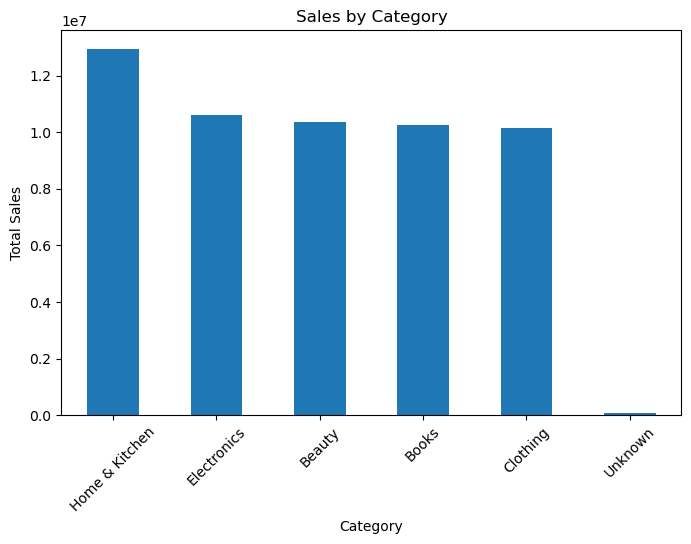

In [19]:
#Visualization
category_sales = df.groupby("Category")["Final_Amount"].sum()
category_sales
#chart
import matplotlib.pyplot as plt
category_sales.sort_values(ascending=False).plot(kind = "bar",figsize = (8,5))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation =45)
plt.show()

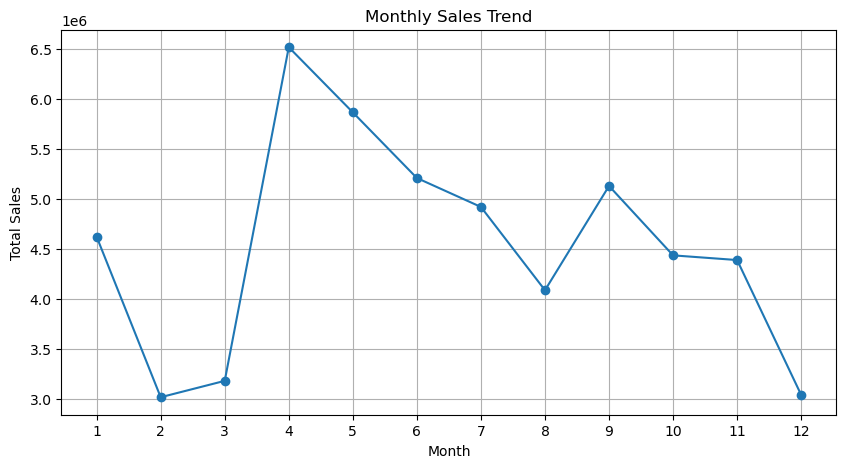

In [20]:
monthly_sales = df.groupby("Month")["Final_Amount"].sum()

monthly_sales.plot(
    kind = "line",
    marker = "o",
    figsize = (10,5)
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))
plt.grid()
plt.show()
#plt.title("Monthly Sales Trend")

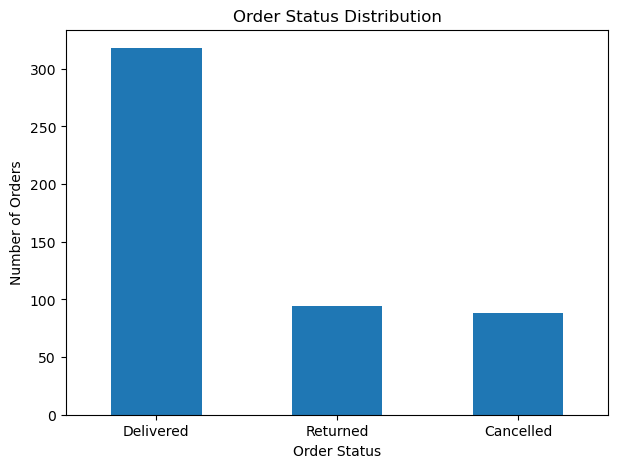

In [21]:
order_status_count = df["Order_Status"].value_counts()

order_status_count.plot(
    kind = "bar",
    figsize = (7,5)
)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation = 0)
plt.show()

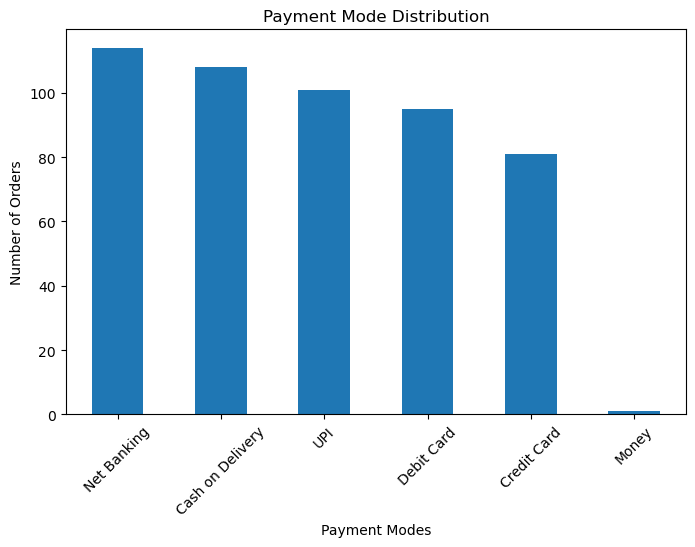

In [22]:
payment_count = df["Payment_Modes"].value_counts()

payment_count.plot(
    kind = "bar",
    figsize = (8,5)
)
plt.title("Payment Mode Distribution")
plt.xlabel("Payment Modes")
plt.ylabel("Number of Orders")
plt.xticks(rotation =45)
plt.show()


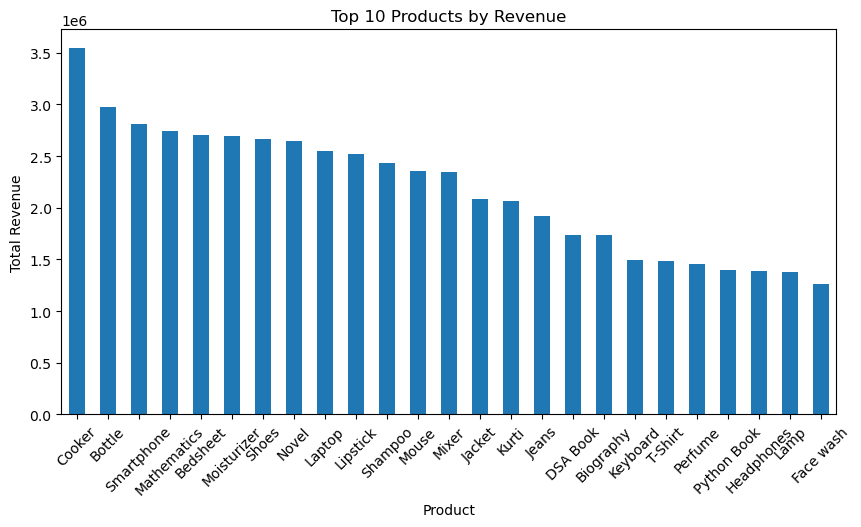

In [23]:
product_revenue = df.groupby("Product")["Final_Amount"].sum()

top_products = product_revenue.sort_values(ascending = False)
top_products.plot(
    kind ="bar",
    figsize = (10,5)
)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [24]:
category_sales.idxmax(),category_sales.max()

(np.str_('Home & Kitchen'), 12950362.1)

In [25]:
city_sales.idxmax(),city_sales.max()


(np.str_('Bangalore'), 6962751.6)

In [26]:
monthly_sales.idxmax(),monthly_sales.max()


(np.int32(4), 6516336.45)

In [27]:
product_revenue.idxmax(),product_revenue.max()


(np.str_('Cooker'), 3548563.3)

In [28]:
payment_count.idxmax(),payment_count.max()


(np.str_('Net Banking'), 114)

In [29]:
order_status_count.idxmax(),order_status_count.max()

(np.str_('Delivered'), 318)

# BUSINESS INSIGHTS

## 1. Category Insight
Home & Kitchen generated the highest revenue amomg all product catgories, with total sales of approximately 12.95 million rupees.

## 2. City Insight
Bangalore generated the highest revenue among all cities , with total sales of approximately 6.96 million rupees.

## 3. Monthly Sales Insight
April recorded the highest monthly sales, generating approximately 6.52 million rupees in revenue.

## 4. Product Insight
Cooker was the highest-revenue product,generating approxiamtely 3.55million rupees in sales.

## 5.Payment Method Insight
Net Banking was the most freequently used payment method , with 114 orders.

## 6.Order Status Insight
Delivered was the most common order status,with 318 orders successfully delivered.


# BUSINESS RECOMMENDATIONS

1. The company should focus more on the Home and Kitchen category because it generated the highest revenue.

2. Bangalore should be considered an important market because it recorded the highest city-wise revenue.

3. The company can study the factors behind the high sales in April and use similar strategies in other months .

4. The company should promote high performing products such as Cookers to increase revenue.

5. Since Net Banking was the most frequently used payment method, the company should continue providing a smooth and secure Net Banking experience.

6. The company should monitor cancelled and returned orders to identify possible reasons and improve customer satisfaction.

# CONCLUSION

This project analyzed customer orders , sales , products , categories , cities , payment methods , and order statuses.

The analysis helped identify the highest-performing category , city , product , month , and payment method. These 
insights can help the business improve sales strategies , focus on high-performing products and markets, and improve 
customer satisfaction.

Overall, the project demonstrates how Pandas and data analysis techniques can be used to convert raw sales data into 
meaningfull business insights.